In [2]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# simulating data
np.random.seed(42)
n_matrices = 3
shape = (4, 4)
A_list = [np.random.randn(*shape) for _ in range(n_matrices)]
true_alphas = np.array([0.5, -1.2, 0.8])
T_true = sum(a * M for a, M in zip(true_alphas, A_list))
noise_std = 0.1
T_obs = T_true + np.random.normal(0, noise_std, size=shape)

# flatten for vector computations
A_stack = np.stack([M.flatten() for M in A_list], axis=1) 
T_flat  = T_obs.flatten()
N_data  = T_flat.size

/tmp/ipykernel_104155/4292663280.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


lower bound, mean, upper bound
0: [0.50200861 0.52954752 0.55672772]
1: [-1.24784518 -1.219533   -1.19041979]
2: [0.77422667 0.8025627  0.83089362]


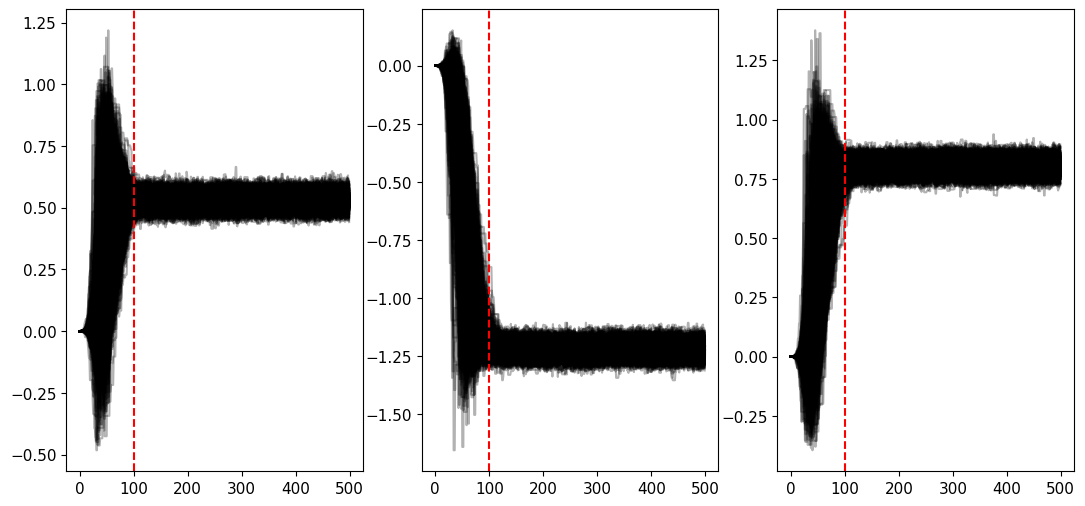

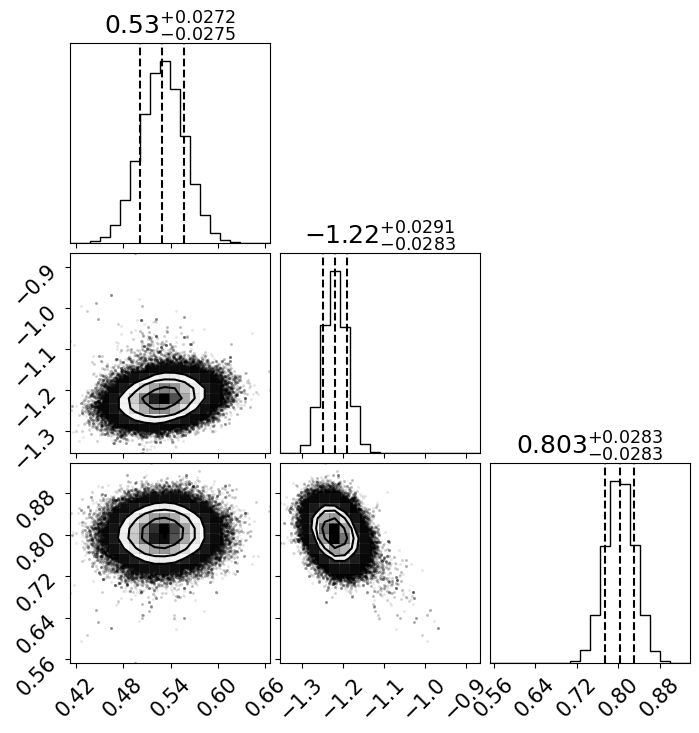

In [12]:
# defining prior and stuff
def log_prior(alpha):
    if np.any(np.abs(alpha) > 1e3):  # simple bound to keep sampler stable
        return -np.inf
    return -0.5 * np.sum((alpha / 2.0)**2)  # Gaussian prior centered ad 0 and sigma 2

def log_likelihood(alpha):
    mu = A_stack.dot(alpha)        # linear combination predicted T_flat
    resid = T_flat - mu
    return -0.5 * np.sum((resid / noise_std)**2) \
           - N_data * np.log(noise_std * np.sqrt(2*np.pi))  # log-likelihood

def log_probability(alpha):
    lp = log_prior(alpha)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(alpha)

# set up the properties of the problem.
ndim, nwalkers, nsampler = len(A_list), 1000, 500

# initial guess: all matrices are working together at the same rate
theta_guess = np.zeros(ndim)

pos = [theta_guess + 1e-4*np.random.randn(ndim) for i in range(nwalkers)]

# Create the sampler.
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

tmp = sampler.run_mcmc(pos, nsampler)

sampler.chain.shape

cutoff = 100

fig, axes = plt.subplots(ncols=3, nrows=1)
fig.set_size_inches(13,6)
plt.rcParams.update({'font.size': 15})
axes[0].plot(sampler.chain[:, :, 0].transpose(), color='black', alpha=0.3)
axes[0].axvline(cutoff, ls='dashed', color='red')
axes[1].plot(sampler.chain[:, :, 1].transpose(), color='black', alpha=0.3)
axes[1].axvline(cutoff, ls='dashed', color='red')
axes[2].plot(sampler.chain[:, :, 2].transpose(), color='black', alpha=0.3)
axes[2].axvline(cutoff, ls='dashed', color='red')
fig.show()

samples = sampler.chain[:, cutoff:, :].reshape((-1, ndim))
samples.shape

print("lower bound, mean, upper bound")
for k in range(len(samples[0])):
    summ = np.percentile(samples[:, k], [16, 50, 84])
    print(f"{k}: {summ}")

fig = corner.corner(samples, truths=[1, 1, 1],
                    quantiles=[0.160, 0.50, 0.840], show_titles=True, title_fmt=.3)
font = {'size'   : 11}
plt.rc('font', **font)
#fig.savefig("cornerplot2.pdf")

In [10]:
print(samples[0])

[ 0.55282037 -1.16748316  0.75662793]
